# Machine Learning Models - YouTube Sentiment Classification

Trains and evaluates six classifiers on the same TF-IDF feature pipeline:

| # | Model |
|---|-------|
| 1 | Logistic Regression 
| 2 | Linear SVM (OvR) |
| 3 | Naive Bayes | 
| 4 | Decision Tree | 
| 5 | Random Forest (OvR) | 

Every model shares the same preprocessing, train/test split, and evaluation helpers from `utils_ml.py`.

## 1. Environment Setup

In [18]:
import sys
import os
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.utils import create_spark_session
from src.config import PARQUET_PATH, PROCESSED_PARQUET_PATH, SAVE_DIR

from src.utils_ml import (
    load_data, select_model_columns, sample_dataset, train_test_split,
    build_lr_pipeline, build_svm_pipeline, build_nb_pipeline,
    build_dt_pipeline, build_rf_pipeline,
    evaluate_model, print_evaluation_metrics,
    plot_confusion_matrix, compare_models, save_model,
)

os.makedirs("../results", exist_ok=True)

spark = create_spark_session(app_name="youtube-all-models")
spark.sparkContext.setLogLevel("ERROR")
print("Spark version:", spark.version)

Spark version: 3.5.3


## 2. Data Preparation
Load, select columns, sample 40%, and split 80/20.  
All models share the exact same `train_df` / `test_df`.

In [19]:
clean_df   = load_data(spark, str(PROCESSED_PARQUET_PATH))
model_df   = select_model_columns(clean_df)
sample_df  = sample_dataset(model_df, fraction=0.40, seed=42)
train_df, test_df = train_test_split(sample_df, train_ratio=0.8, seed=42)

print(f"Train rows : {train_df.count():,}")
print(f"Test rows  : {test_df.count():,}")

Train rows : 326,122
Test rows  : 81,310


In [20]:
# Retrieve label order from the training data for confusion matrix axes.
# StringIndexer orders by frequency descending, so we replicate that here.
from pyspark.ml.feature import StringIndexer as _SI

_indexer = _SI(inputCol="Sentiment", outputCol="label").fit(train_df)
CLASS_LABELS = _indexer.labels          # e.g. ['Negative', 'Neutral', 'Positive']
print("Class label order:", CLASS_LABELS)

Class label order: ['Negative', 'Neutral', 'Positive']


## 3. Model Training & Evaluation

### 3.1 Model 1 - Logistic Regression (Baseline)

In [21]:
lr_model       = build_lr_pipeline(max_iter=50, reg_param=0.05).fit(train_df)
lr_preds       = lr_model.transform(test_df)
lr_metrics     = evaluate_model(lr_preds)
print_evaluation_metrics(lr_metrics, "Logistic Regression")


Logistic Regression
  Accuracy : 0.6211
  F1-score : 0.6226
  Precision: 0.6266
  Recall   : 0.6211


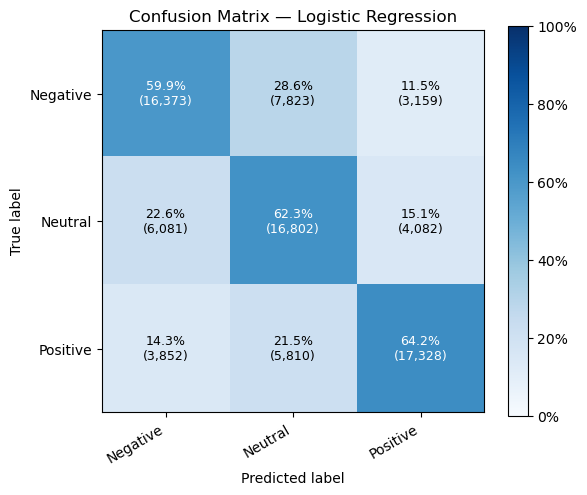

In [22]:
plot_confusion_matrix(lr_preds, CLASS_LABELS, model_name="Logistic Regression")

### 3.2 Model 2 - Linear SVM (OneVsRest)

In [23]:
svm_model      = build_svm_pipeline(max_iter=600, reg_param=0.01).fit(train_df)
svm_preds      = svm_model.transform(test_df)
svm_metrics    = evaluate_model(svm_preds)
print_evaluation_metrics(svm_metrics, "Linear SVM (OvR)")


Linear SVM (OvR)
  Accuracy : 0.6216
  F1-score : 0.6226
  Precision: 0.6247
  Recall   : 0.6216


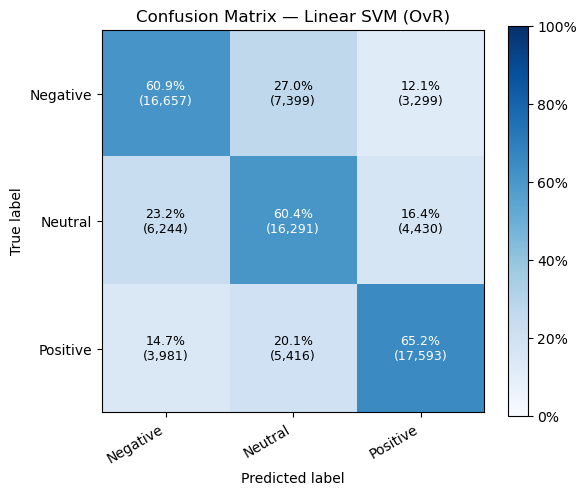

In [24]:
plot_confusion_matrix(svm_preds, CLASS_LABELS, model_name="Linear SVM (OvR)")

### 3.3 Model 3 - Naive Bayes

In [25]:
nb_model       = build_nb_pipeline(smoothing=1.0).fit(train_df)
nb_preds       = nb_model.transform(test_df)
nb_metrics     = evaluate_model(nb_preds)
print_evaluation_metrics(nb_metrics, "Naive Bayes")


Naive Bayes
  Accuracy : 0.5985
  F1-score : 0.5959
  Precision: 0.5979
  Recall   : 0.5985


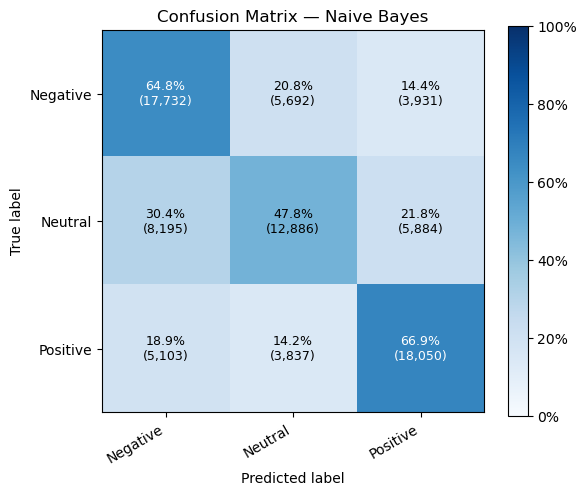

In [26]:
plot_confusion_matrix(nb_preds, CLASS_LABELS, model_name="Naive Bayes")

### 3.4 Model 4 - Decision Tree

In [27]:
dt_model       = build_dt_pipeline(max_depth=6, seed=67).fit(train_df)
dt_preds       = dt_model.transform(test_df)
dt_metrics     = evaluate_model(dt_preds)
print_evaluation_metrics(dt_metrics, "Decision Tree")


Decision Tree
  Accuracy : 0.4392
  F1-score : 0.3457
  Precision: 0.5386
  Recall   : 0.4392


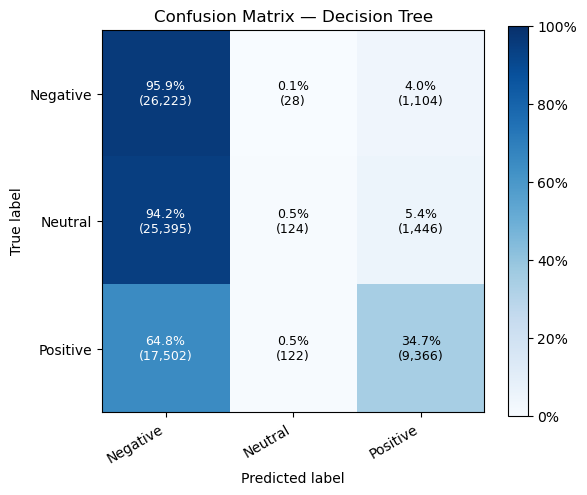

In [28]:
plot_confusion_matrix(dt_preds, CLASS_LABELS, model_name="Decision Tree")

### 3.5 Model 5 - Random Forest

In [29]:
rf_model       = build_rf_pipeline(num_trees=100, max_depth=7, seed=67).fit(train_df)
rf_preds       = rf_model.transform(test_df)
rf_metrics     = evaluate_model(rf_preds)
print_evaluation_metrics(rf_metrics, "Random Forest")


Random Forest
  Accuracy : 0.5462
  F1-score : 0.5453
  Precision: 0.5745
  Recall   : 0.5462


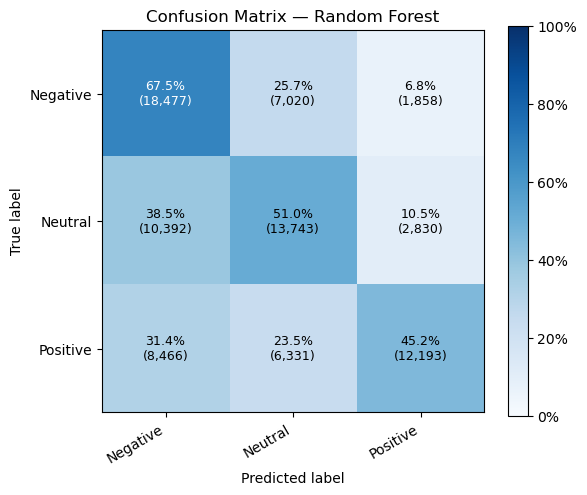

In [30]:
plot_confusion_matrix(rf_preds, CLASS_LABELS, model_name="Random Forest")

### 3.6 Model Comparison
Side-by-side bar chart and summary table for all six models.

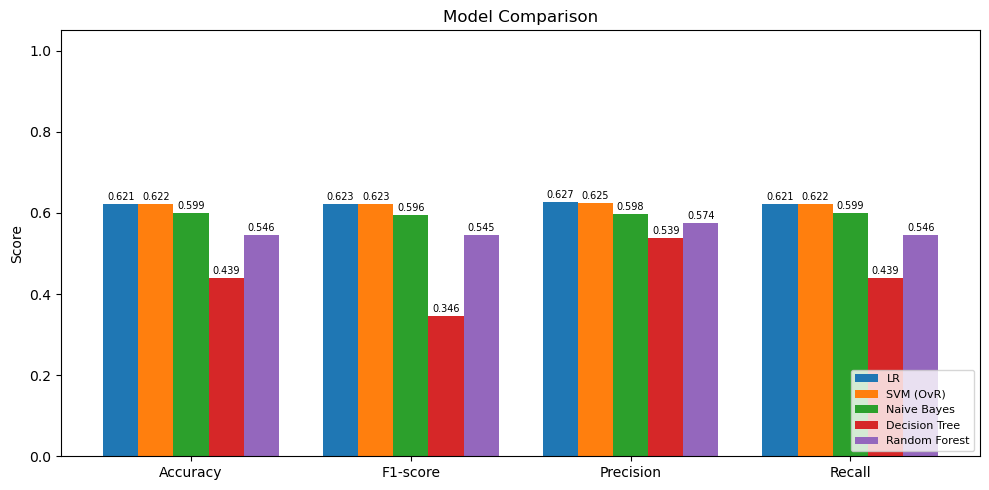

In [31]:
all_results = {
    "LR":           lr_metrics,
    "SVM (OvR)":    svm_metrics,
    "Naive Bayes":  nb_metrics,
    "Decision Tree":dt_metrics,
    "Random Forest":rf_metrics
}

compare_models(all_results)

In [32]:
summary = pd.DataFrame(all_results).T.rename(columns={
    "accuracy": "Accuracy",
    "f1": "F1-score",
    "weightedPrecision": "Precision",
    "weightedRecall": "Recall",
}).sort_values("F1-score", ascending=False)

summary

,Accuracy,F1-score,Precision,Recall
SVM (OvR),0.621584,0.622619,0.624703,0.621584
LR,0.621117,0.622568,0.626586,0.621117
Naive Bayes,0.598549,0.595884,0.597920,0.598549
Random Forest,0.546218,0.545311,0.574470,0.546218
Decision Tree,0.439220,0.345728,0.538622,0.439220


In [33]:
summary.to_csv("../results/model_comparison.csv", index=False)

## 4. Save Best Model

In [34]:
best_name  = summary.index[0]
best_model = {
    "LR":           lr_model,
    "SVM (OvR)":    svm_model,
    "Naive Bayes":  nb_model,
    "Decision Tree":dt_model,
    "Random Forest":rf_model
}[best_name]

save_model(best_model, str(SAVE_DIR / f"youtube_sentiment_{best_name.lower().replace(' ', '_')}_pipeline"))
print(f"Best model: {best_name}  (F1 = {summary.loc[best_name, 'F1-score']:.4f})")

Model saved at: /Users/pedro/Documents/DSAA/2semester/BDA/Project/Big-Data-Analyitics-Project/data/youtube-comment-sentiment/youtube_sentiment_svm_(ovr)_pipeline
Best model: SVM (OvR)  (F1 = 0.6226)
